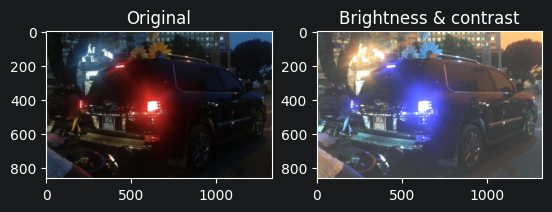

In [6]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

img = cv2.imread("img_plate_3.png")
img_rgb = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)

plt.subplot(1,2,1)
plt.title("Original")
plt.imshow(img_rgb)

# g(x,y) = af(x,y)+ b
alpha = 1.5
beta = 50

img2 = cv2.convertScaleAbs(img, alpha=alpha, beta=beta)

plt.subplot(1,2,2)
plt.title("Brightness & contrast")
plt.imshow(img2)
plt.show()


2. Threshold

Global Threshold

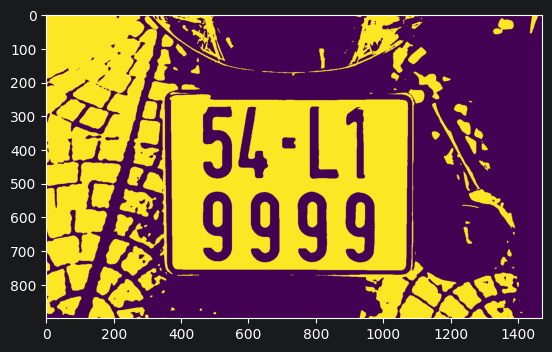

In [9]:
import cv2

img = cv2.imread("img_plate_7.png")
img_rgb = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
gray_image = cv2.cvtColor(img_rgb, cv2.COLOR_BGR2GRAY)

_, thresh = cv2.threshold(gray_image, 120, 255, cv2.THRESH_BINARY)

plt.imshow(thresh)

Adaptive Threshold

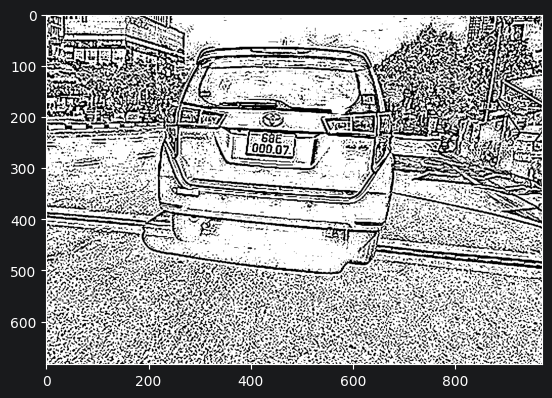

In [15]:
import cv2

img = cv2.imread("img_plate_5.png", 0)

thresh = cv2.adaptiveThreshold(
    img,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    11,
    2
)
thresh_rgb = cv2.cvtColor(thresh, cv2.COLOR_RGB2BGR)

plt.imshow(thresh_rgb)


Otsu Threshold

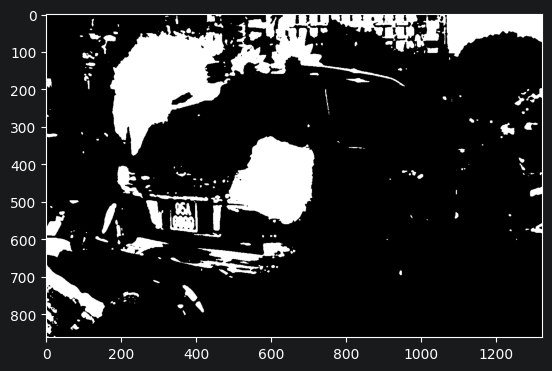

In [12]:
import cv2

img = cv2.imread("img_plate_3.png",0)

blur = cv2.GaussianBlur(img, (3,3), 0)
_,thresh = cv2.threshold(
    blur,
    0,
    255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)
thresh_rgb = cv2.cvtColor(thresh, cv2.COLOR_RGB2BGR)
plt.imshow(thresh_rgb)

3. Morphological

In [7]:
def show(inv, out, operation):
    plt.subplot(1,2,1)
    plt.title("Original Image")
    plt.imshow(inv, cmap="gray")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.title(f"{operation} image")
    plt.imshow(out, cmap="gray")
    plt.axis("off")


Erosion

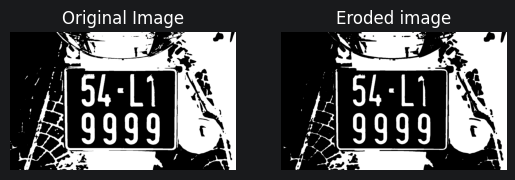

In [15]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("img_plate_7.png",0)

thresh = cv2.threshold(img,0,255,cv2.THRESH_BINARY + cv2.THRESH_OTSU)[1]

k =  np.ones((5,5), np.uint8)
inv = cv2.bitwise_not(thresh)
out = cv2.erode(inv, k ,1)

show(inv, out, "Eroded")

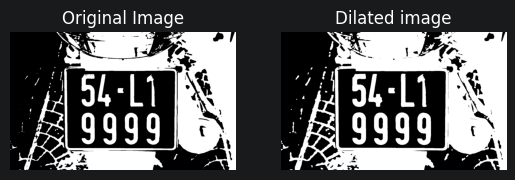

In [16]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("img_plate_7.png",0)
thresh = cv2.threshold(img, 0 ,255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)[1]

k = np.ones((5,5), np.uint8)
inv = cv2.bitwise_not(thresh)
out = cv2.dilate(inv, k ,1)

show(inv, out,"Dilated")

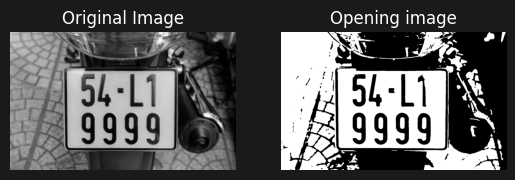

In [18]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("img_plate_7.png",0)
bin = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)[1]

k = np.ones((3,3), np.uint8)
opened = cv2.morphologyEx(bin, cv2.MORPH_OPEN, k)
show(img, opened, "Opening")

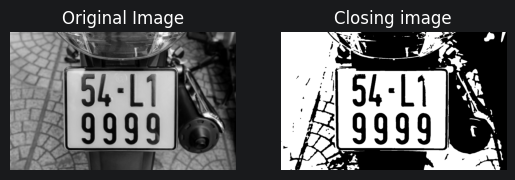

In [19]:
import  cv2
import  numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("img_plate_7.png",0)
bin = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)[1]

k =np.ones((3,3), np.uint8)
opened = cv2.morphologyEx(bin, cv2.MORPH_CLOSE, k)
show(img, opened, "Closing")

4. Contour

(np.float64(-0.5), np.float64(453.5), np.float64(385.5), np.float64(-0.5))

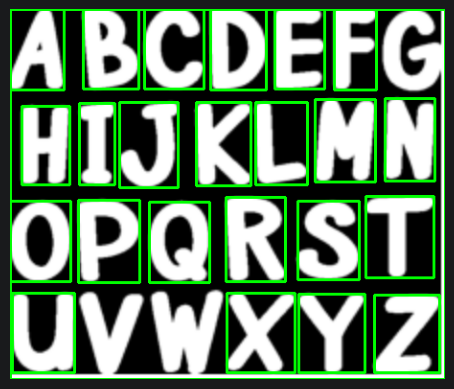

In [25]:
import cv2

img = cv2.imread("chucai.png")

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

_,thresh = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
contours,_ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

output = img.copy()
characters = []
for cnt in contours:
    x,y,w,h = cv2.boundingRect(cnt)

    if w > 20 and h > 20:
        cv2.rectangle(output, (x,y), (x+w, y+h), (0,255,0),2)
        char = thresh[y:y+h,x:x+w]
        char = cv2.resize(char, (32,32))
        characters.append(char)

plt.imshow(output)
plt.axis("off")


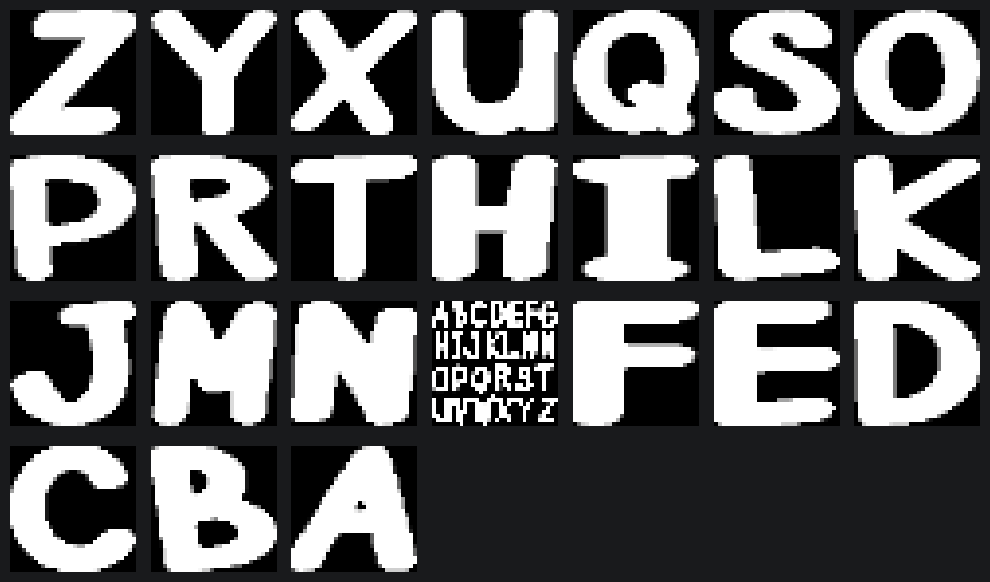

In [24]:
plt.figure(figsize=(10, 6))

for i, char in enumerate(characters[:26]):
    plt.subplot(4,7, i+1)
    plt.imshow(char, cmap='gray')
    plt.axis("off")

plt.tight_layout()
plt.show()


5. Deskew
6. Nhận dạng ký tự sử dụng Teseract
7. Ví dụ xử lý một ảnh biển số

ảnh gốc

(np.float64(-0.5), np.float64(1471.5), np.float64(899.5), np.float64(-0.5))

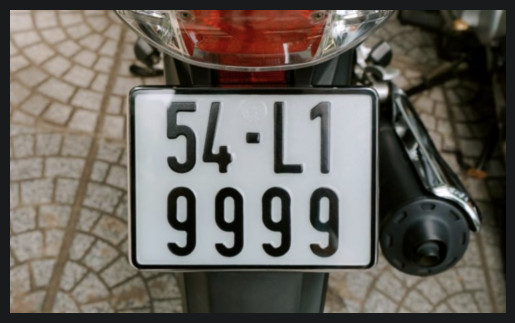

In [26]:
import cv2
import matplotlib.pyplot as plt

original = cv2.imread('img_plate_7.png')
plt.imshow(cv2.cvtColor(original, cv2.COLOR_RGB2BGR))
plt.axis('off')

5.1 Các bước biển đổi


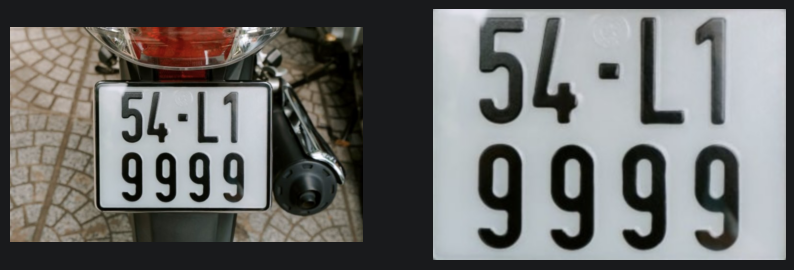

In [29]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pytesseract

img = cv2.imread('img_plate_7.png')

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
blur = cv2.bilateralFilter(gray, 11, 17, 17)

edged = cv2.Canny(blur, 30, 200)

cnts, _ = cv2.findContours(edged.copy(), cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
cnts = sorted(cnts, key=cv2.contourArea, reverse=True)[:10]

screenCnt = None
for c in cnts:
    peri = cv2.arcLength(c, True)
    approx = cv2.approxPolyDP(c, 0.02 * peri, True)
    if len( approx) == 4:
        screenCnt = approx
        break
if screenCnt is not None:
    pts = screenCnt.reshape(4, 2)
    rect = np.zeros((4,2), dtype="float32")

    s = pts.sum(axis=1)
    rect[0] = pts[np.argmin(s)] # điểm trên-trái là điểm có tổng
    rect[2] = pts[np.argmax(s)] # điểm dưới-phải là điểm có tổng x + y lớn nhất
    diff = np.diff(pts, axis=1)
    rect[1] = pts[np.argmin(diff)]
    rect[3] = pts[np.argmax(diff)]

    #tính độ dài các cạnh
    (tl, tr, br, bl) = rect
    widthA = np.sqrt(((br[0] - bl[0]) ** 2) + ((br[1] - bl[1]) ** 2))
    widthB = np.sqrt(((tr[0] - tl[0]) ** 2) + ((tr[1] - tl[1]) ** 2))
    maxWidth = max(int(widthA), int(widthB))

    heightA = np.sqrt(((tr[0] - br[0]) ** 2) + ((tr[1] - br[1]) ** 2))
    heightB = np.sqrt(((tl[0] - bl[0]) ** 2 + (tl[1] - bl[1]) ** 2))

    maxHeight = max(int(heightA), int(heightB))

    # tọa độ 4 điểm của hình chữ nhật tiêu chuẩn
    dst = np.array([
        [0, 0],
        [maxWidth - 1, 0],
        [maxWidth - 1, maxHeight - 1],
        [0, maxHeight - 1]], dtype="float32")

    # Ma trận biến đổi M
    M = cv2. getPerspectiveTransform(rect, dst)

    # Áp dụng biến đổi
    warped = cv2.warpPerspective(img, M, (maxWidth, maxHeight))

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_RGB2BGR))
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(cv2.cvtColor(warped, cv2.COLOR_RGB2BGR))
    plt.axis('off')
